# Retail Sales Data Analysis

## Objective
The objective of this project is to analyse retail sales data to understand
overall sales performance, identify top-performing products and categories,
and provide actionable insights to support inventory and sales decisions.


## Questions to answers:

How does customer age and gender influence their purchasing behavior?

Are there discernible patterns in sales across different time periods?

Which product categories hold the highest appeal among customers?

What are the relationships between age, spending, and product preferences?

How do customers adapt their shopping habits during seasonal trends?

Are there distinct purchasing behaviors based on the number of items bought per transaction?

What insights can be gleaned from the distribution of product prices within each category?

In [144]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings 
warnings.simplefilter("ignore")

In [146]:
df=pd.read_csv("retail_sales_dataset.csv")
df.head(10)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
5,6,2023-04-25,CUST006,Female,45,Beauty,1,30,30
6,7,2023-03-13,CUST007,Male,46,Clothing,2,25,50
7,8,2023-02-22,CUST008,Male,30,Electronics,4,25,100
8,9,2023-12-13,CUST009,Male,63,Electronics,2,300,600
9,10,2023-10-07,CUST010,Female,52,Clothing,4,50,200


In [148]:
df.shape

(1000, 9)

In [150]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [11]:
#we need to change date to date and time varaible from object

In [17]:
df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d')
df['Date']

0     2023-11-24
1     2023-02-27
2     2023-01-13
3     2023-05-21
4     2023-05-06
         ...    
995   2023-05-16
996   2023-11-17
997   2023-10-29
998   2023-12-05
999   2023-04-12
Name: Date, Length: 1000, dtype: datetime64[ns]

In [152]:
df['Transaction ID'].duplicated().value_counts()

Transaction ID
False    1000
Name: count, dtype: int64

In [154]:
df.columns


Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')

In [156]:
df.columns.tolist()

['Transaction ID',
 'Date',
 'Customer ID',
 'Gender',
 'Age',
 'Product Category',
 'Quantity',
 'Price per Unit',
 'Total Amount']

In [158]:
df["Gender"].unique()

array(['Male', 'Female'], dtype=object)

In [47]:
df["Gender"].value_counts()

Gender
Female    510
Male      490
Name: count, dtype: int64

In [51]:
df["Product Category"].value_counts()

Product Category
Clothing       351
Electronics    342
Beauty         307
Name: count, dtype: int64

In [53]:
df["Product Category"].unique()

array(['Beauty', 'Clothing', 'Electronics'], dtype=object)

In [55]:
df["Product Category"].nunique()

3

In [57]:
df["Quantity"].unique()

array([3, 2, 1, 4])

In [59]:
df["Quantity"].nunique()

4

In [61]:
df["Quantity"].value_counts()

Quantity
4    263
1    253
2    243
3    241
Name: count, dtype: int64

In [63]:
df["Price per Unit"].unique()

array([ 50, 500,  30,  25, 300])

In [65]:
df["Price per Unit"].nunique()

5

In [67]:
df["Price per Unit"].value_counts()

Price per Unit
50     211
25     210
500    199
300    197
30     183
Name: count, dtype: int64

In [19]:
#Now checking duplicate values

In [27]:
df.duplicated().value_counts()

False    1000
Name: count, dtype: int64

In [39]:
df.duplicated(
    subset=['Date', 'Customer ID'],
    keep=False
).value_counts()


False    1000
Name: count, dtype: int64

In [29]:
for col in df.columns:
    print(col)
    print(df[col].duplicated().value_counts(), '\n')


Transaction ID
Transaction ID
False    1000
Name: count, dtype: int64 

Date
Date
True     655
False    345
Name: count, dtype: int64 

Customer ID
Customer ID
False    1000
Name: count, dtype: int64 

Gender
Gender
True     998
False      2
Name: count, dtype: int64 

Age
Age
True     953
False     47
Name: count, dtype: int64 

Product Category
Product Category
True     997
False      3
Name: count, dtype: int64 

Quantity
Quantity
True     996
False      4
Name: count, dtype: int64 

Price per Unit
Price per Unit
True     995
False      5
Name: count, dtype: int64 

Total Amount
Total Amount
True     982
False     18
Name: count, dtype: int64 



In [71]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [73]:
#since there is no null values we will check outliers

In [75]:
continuous=['Total Amount']

discrete_count=['Age','Quantity',"Price per Unit"]

Categorical = ['Gender','Product Category','Transaction ID','Customer ID']

Time_Series = ['Date']

In [77]:
df[continuous].describe()

,Total Amount
count,1000.000000
mean,456.000000
std,559.997632
min,25.000000
25%,60.000000
50%,135.000000
75%,900.000000
max,2000.000000


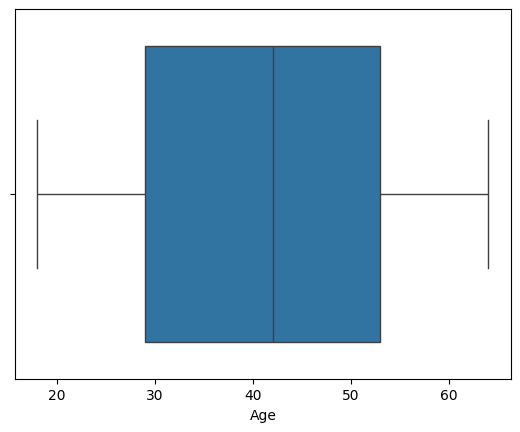

In [87]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(x=df
            ["Age"])
plt.show()

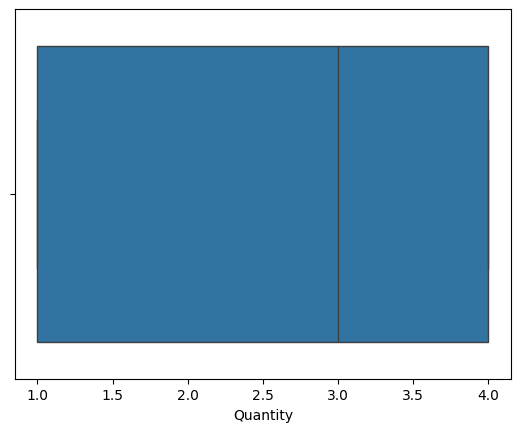

In [89]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(x=df
            ["Quantity"])
plt.show()

In [91]:
numeric_cols = ['Age', 'Quantity', 'Price per Unit', 'Total Amount']


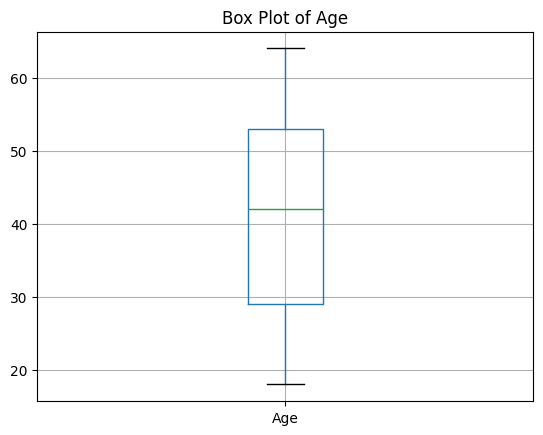

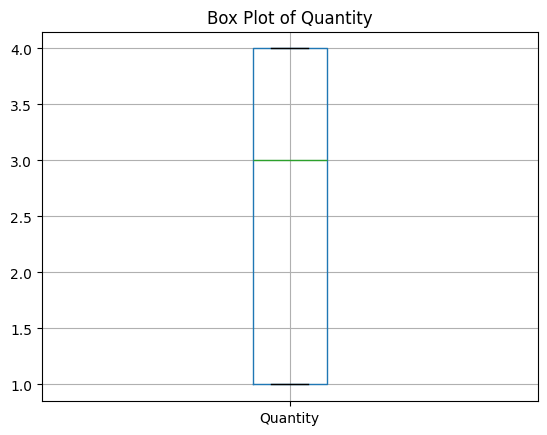

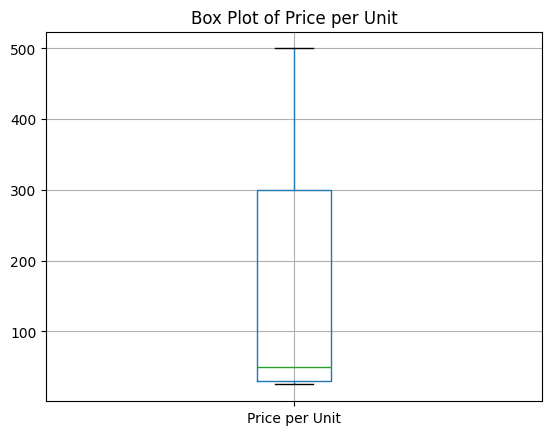

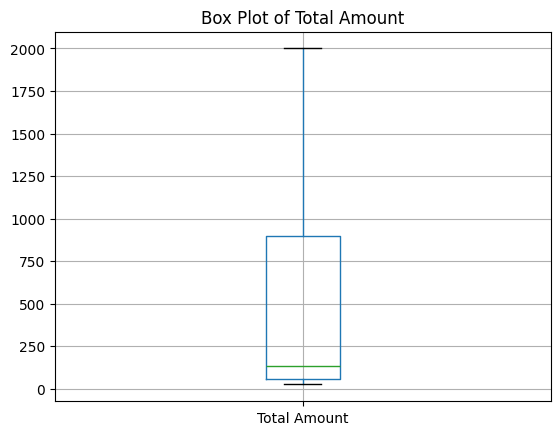

In [95]:
import matplotlib.pyplot as plt

for col in numeric_cols:
    df.boxplot(column=col)
    plt.title(f'Box Plot of {col}')
    plt.show()


In [97]:
def iqr_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    return df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]

iqr_outliers(df, 'Price per Unit')


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount


In [99]:
from scipy.stats import zscore

df['z_score'] = zscore(df['Price per Unit'])
df[df['z_score'].abs() > 3]


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,z_score


## Key Retail KPIs

- Total Sales Revenue
- Sales Trend Over Time
- Product-Level Sales Performance
- Category-Level Sales Performance


In [101]:
df[['Age','Quantity','Price per Unit','Total Amount']].describe()


,Age,Quantity,Price per Unit,Total Amount
count,1000.00000,1000.000000,1000.000000,1000.000000
mean,41.39200,2.514000,179.890000,456.000000
std,13.68143,1.132734,189.681356,559.997632
min,18.00000,1.000000,25.000000,25.000000
25%,29.00000,1.000000,30.000000,60.000000
50%,42.00000,3.000000,50.000000,135.000000
75%,53.00000,4.000000,300.000000,900.000000
max,64.00000,4.000000,500.000000,2000.000000


In [103]:
age_bins = [0, 18, 25, 35, 45, 60, 100]
age_labels = ['<18', '18–25', '26–35', '36–45', '46–60', '60+']

df['Age Group'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels)


In [107]:
df.groupby('Gender')['Total Amount'].describe()


,count,mean,std,min,25%,50%,75%,max
Gender,,,,,,,,
Female,510.0,456.549020,554.299371,25.0,60.0,150.0,900.0,2000.0
Male,490.0,455.428571,566.433809,25.0,60.0,120.0,900.0,2000.0


In [109]:
df.groupby('Gender')['Total Amount'].sum()


Gender
Female    232840
Male      223160
Name: Total Amount, dtype: int64

In [111]:
df.groupby('Gender')['Quantity'].describe()


,count,mean,std,min,25%,50%,75%,max
Gender,,,,,,,,
Female,510.0,2.545098,1.132189,1.0,2.0,3.0,4.0,4.0
Male,490.0,2.481633,1.133551,1.0,1.0,2.0,4.0,4.0


In [113]:
df.groupby('Age Group')['Total Amount'].describe()


,count,mean,std,min,25%,50%,75%,max
Age Group,,,,,,,,
<18,21.0,534.047619,664.365523,30.0,75.0,120.0,1000.0,2000.0
18–25,148.0,495.506757,592.725671,25.0,50.0,150.0,925.0,2000.0
26–35,205.0,480.390244,577.636830,25.0,75.0,150.0,900.0,2000.0
36–45,202.0,454.801980,577.539997,25.0,60.0,120.0,900.0,2000.0
46–60,331.0,446.752266,519.780501,25.0,75.0,150.0,900.0,2000.0
60+,93.0,357.258065,543.009687,25.0,50.0,100.0,300.0,2000.0


In [117]:
df.groupby('Age Group')['Quantity'].describe()


,count,mean,std,min,25%,50%,75%,max
Age Group,,,,,,,,
<18,21.0,2.571429,1.121224,1.0,2.00,3.0,3.0,4.0
18–25,148.0,2.418919,1.154780,1.0,1.00,2.0,3.0,4.0
26–35,205.0,2.634146,1.123634,1.0,2.00,3.0,4.0,4.0
36–45,202.0,2.504950,1.129644,1.0,1.25,2.5,4.0,4.0
46–60,331.0,2.510574,1.121029,1.0,2.00,2.0,4.0,4.0
60+,93.0,2.419355,1.173277,1.0,1.00,2.0,4.0,4.0


## Q1: How are total retail sales trending over time?

**Why it matters:** Indicates overall business health and seasonality.


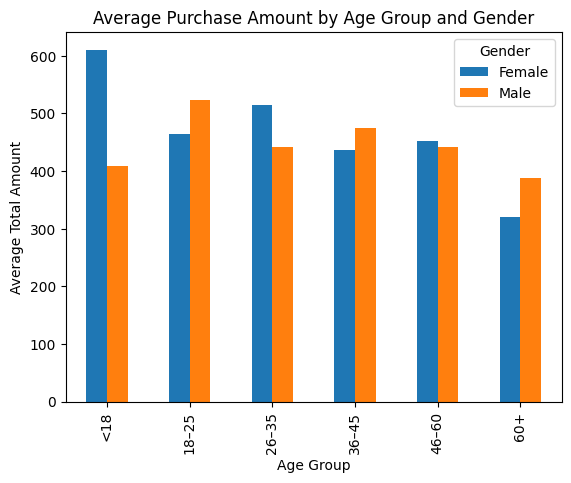

In [119]:
import matplotlib.pyplot as plt

pivot = df.pivot_table(
    values='Total Amount',
    index='Age Group',
    columns='Gender',
    aggfunc='mean'
)

pivot.plot(kind='bar')
plt.ylabel('Average Total Amount')
plt.title('Average Purchase Amount by Age Group and Gender')
plt.show()


## Q2: Which products generate the highest sales?

**Why it matters:** Helps prioritise inventory and merchandising.


In [125]:
daily_sales = df.groupby('Date')['Total Amount'].sum()
daily_sales

Date
2023-01-01    3600
2023-01-02    1765
2023-01-03     600
2023-01-04    1240
2023-01-05    1100
              ... 
2023-12-27     700
2023-12-28    2075
2023-12-29    3400
2023-12-31      50
2024-01-01    1530
Name: Total Amount, Length: 345, dtype: int64

In [133]:
df['Month'] = df['Date'].dt.to_period('M')
monthly_sales = df.groupby('Month')['Total Amount'].sum()
monthly_sales


Month
2023-01    35450
2023-02    44060
2023-03    28990
2023-04    33870
2023-05    53150
2023-06    36715
2023-07    35465
2023-08    36960
2023-09    23620
2023-10    46580
2023-11    34920
2023-12    44690
2024-01     1530
Freq: M, Name: Total Amount, dtype: int64

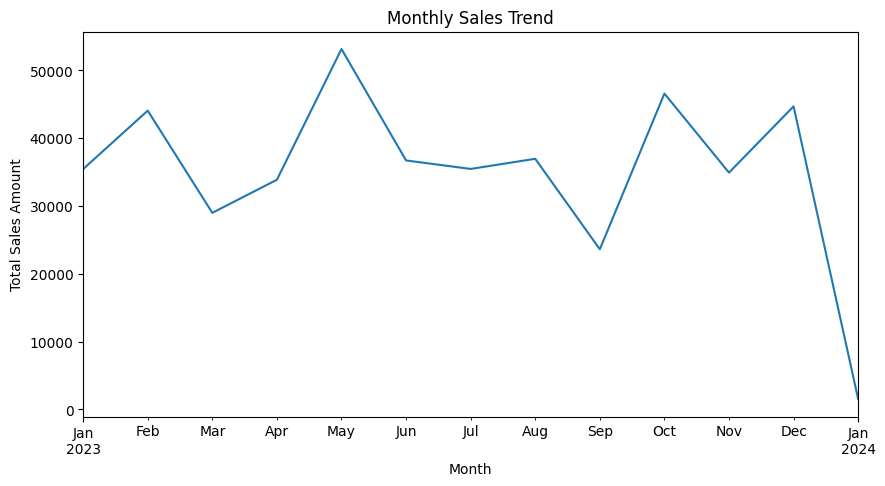

In [135]:
monthly_sales.plot(kind='line', figsize=(10,5))
plt.ylabel('Total Sales Amount')
plt.title('Monthly Sales Trend')
plt.show()


In [137]:
df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)


Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64

In [139]:
df.groupby('Product Category')['Total Amount'].mean().sort_values(ascending=False)


Product Category
Beauty         467.475570
Electronics    458.786550
Clothing       443.247863
Name: Total Amount, dtype: float64

## Q3: Which categories contribute most to revenue?

**Why it matters:** Supports category-level planning and promotions.


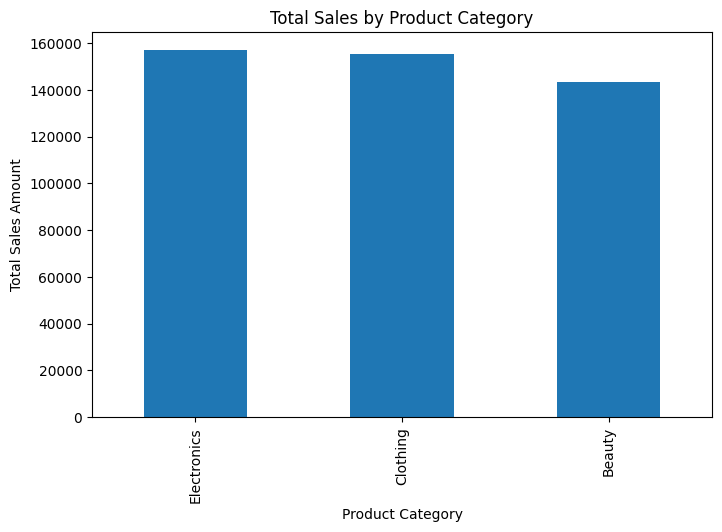

In [141]:
import matplotlib.pyplot as plt

category_sales = (
    df.groupby('Product Category')['Total Amount']
    .sum()
    .sort_values(ascending=False)
)

category_sales.plot(kind='bar', figsize=(8,5))
plt.ylabel('Total Sales Amount')
plt.title('Total Sales by Product Category')
plt.show()


## Key Insights

- Retail sales exhibit clear trends over time, indicating seasonality.
- A limited set of products drives a large portion of total sales.
- Certain categories consistently outperform others in revenue contribution.

## Business Recommendations

- Focus inventory and promotions on high-performing products and categories.
- Use sales trends to plan seasonal campaigns and stock levels.
- Review low-performing categories to optimise pricing or assortment.
